In [10]:
'''markdown
 New Tyres Inventory Analytics

Inventory Optimization and Product Performance Analysis

Author: Georgina Casas

Tools Used:
- Python
- Pandas
- Matplotlib
- Google Colab

Project Overview

This project analyzes inventory and sales performance for a tire distribution business.

The objective is to identify:

- High-demand products
- Inventory investment risks
- Product rotation patterns
- Opportunities to optimize purchasing decisions
The analysis was conducted using a simulated dataset containing 90 days of inventory activity across 200 tire products. ##


Business Problem

Inventory management is a critical challenge for tire distributors.

Excess inventory can tie up capital, while insufficient inventory can lead to missed sales opportunities.

The purpose of this project is to analyze product performance and inventory levels to support better purchasing and inventory planning decisions.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

# Catalog


medidas = [
    "205/55R16","195/65R15","185/60R15","225/45R17",
    "215/60R16","235/75R15","245/70R16","265/70R17",
    "275/65R18","12R22.5","11R22.5","295/80R22.5"
]

marcas = [
    "Michelin",
    "Goodyear",
    "Pirelli",
    "Bridgestone",
    "Hankook",
    "Firestone",
    "Continental"
]

categorias = [
    "Sedan",
    "SUV",
    "Pickup",
    "Camion"
]


# We created a dataset with 200 tires.


n = 200

catalogo = pd.DataFrame({
    "llanta_id": range(1, n+1),
    "medida": np.random.choice(medidas, n),
    "marca": np.random.choice(marcas, n),
    "categoria": np.random.choice(categorias, n),
    "costo": np.random.randint(900, 4500, n),
    "inventario_inicial": np.random.randint(10, 120, n)
})

catalogo.head()

,llanta_id,medida,marca,categoria,costo,inventario_inicial
0,1,245/70R16,Bridgestone,Pickup,1396,15
1,2,225/45R17,Continental,SUV,1795,67
2,3,11R22.5,Pirelli,SUV,3107,53
3,4,265/70R17,Firestone,Pickup,4446,54
4,5,215/60R16,Michelin,Camion,1751,41


In [11]:
catalogo.to_csv("catalogo_llantas.csv", index=False)

print("Catalogo guardado")

from google.colab import files

files.download("catalogo_llantas.csv")

Catalogo guardado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
#create the historical

from datetime import datetime, timedelta

dias = 90

fechas = pd.date_range(
    start="2025-01-01",
    periods=dias,
    freq="D"
)

historico = []

for _, row in catalogo.iterrows():

    inventario = row["inventario_inicial"]

    for fecha in fechas:

        ventas = np.random.poisson(2)

        inventario = max(0, inventario - ventas)

        if inventario < 15:

            reposicion = np.random.randint(30,80)

            inventario += reposicion

        historico.append([
            fecha,
            row["llanta_id"],
            row["medida"],
            row["marca"],
            inventario,
            ventas
        ])

historico = pd.DataFrame(
    historico,
    columns=[
        "fecha",
        "llanta_id",
        "medida",
        "marca",
        "inventario",
        "ventas"
    ]
)

historico.head()

,fecha,llanta_id,medida,marca,inventario,ventas
0,2025-01-01,1,245/70R16,Bridgestone,15,0
1,2025-01-02,1,245/70R16,Bridgestone,15,0
2,2025-01-03,1,245/70R16,Bridgestone,15,0
3,2025-01-04,1,245/70R16,Bridgestone,51,1
4,2025-01-05,1,245/70R16,Bridgestone,50,1


In [13]:
historico.to_csv(
    "historico_llantas.csv",
    index=False
)

print("Historico guardado")

from google.colab import files
files.download("historico_llantas.csv")

Historico guardado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:

# EXPLORATORY DATA ANALYSIS (EDA)

historico = pd.read_csv("historico_llantas.csv")

historico.head()
historico.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   fecha       18000 non-null  object
 1   llanta_id   18000 non-null  int64 
 2   medida      18000 non-null  object
 3   marca       18000 non-null  object
 4   inventario  18000 non-null  int64 
 5   ventas      18000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 843.9+ KB


In [16]:
historico.describe()


,llanta_id,inventario,ventas
count,18000.000000,18000.000000,18000.000000
mean,100.500000,46.649778,2.003222
std,57.735909,20.564866,1.415702
min,1.000000,15.000000,0.000000
25%,50.750000,30.000000,1.000000
50%,100.500000,45.000000,2.000000
75%,150.250000,62.000000,3.000000
max,200.000000,116.000000,10.000000


In [17]:

ventas_totales = historico["ventas"].sum()

print("Ventas Totales:", ventas_totales)

Ventas Totales: 36058


In [18]:
inventario_promedio = historico["inventario"].mean()

print("Inventario Promedio:", round(inventario_promedio,2))

Inventario Promedio: 46.65


In [19]:
# top20_sales

top20_ventas = (
    historico
    .groupby("medida")["ventas"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top20_ventas

,ventas
medida,
295/80R22.5,4879
245/70R16,3963
275/65R18,3430
265/70R17,3353
185/60R15,3109
12R22.5,3029
215/60R16,2771
225/45R17,2553
11R22.5,2480


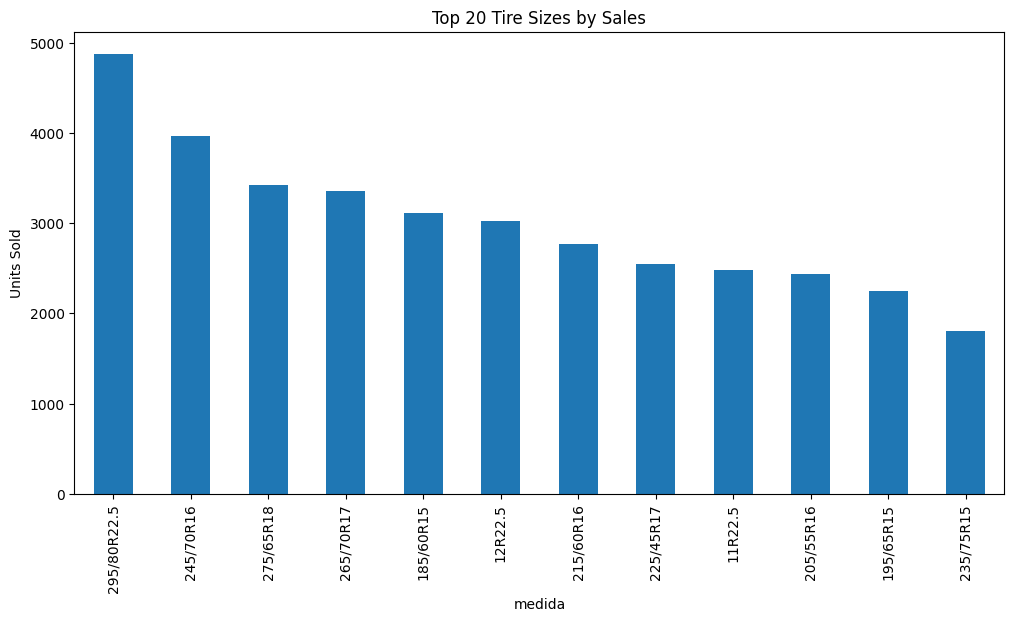

In [20]:
#top 20 plot
plt.figure(figsize=(12,6))

top20_ventas.plot(kind="bar")

plt.title("Top 20 Tire Sizes by Sales")
plt.ylabel("Units Sold")

plt.show()

In [21]:
#sales by brand
ventas_marca = (
    historico
    .groupby("marca")["ventas"]
    .sum()
    .sort_values(ascending=False)
)

ventas_marca

,ventas
marca,
Michelin,7332
Bridgestone,6328
Pirelli,6047
Firestone,5555
Hankook,3690
Continental,3598
Goodyear,3508


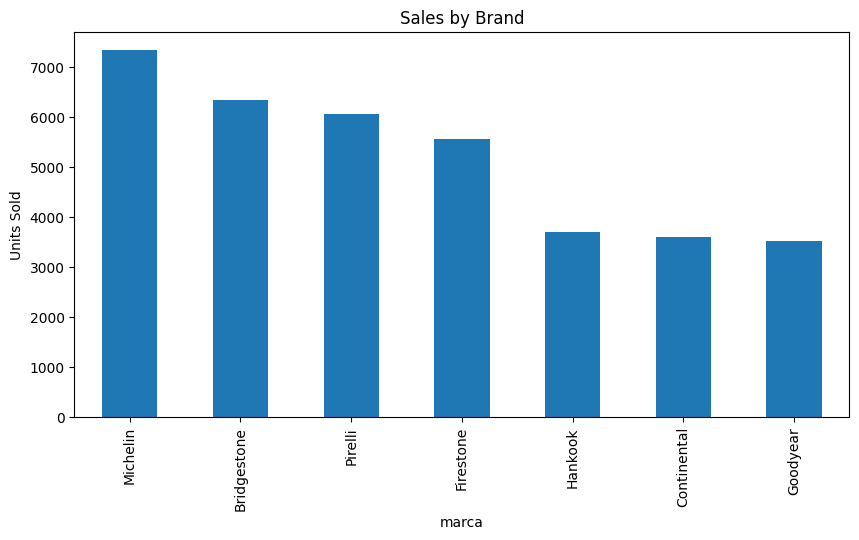

In [22]:
#sales by brand plot

plt.figure(figsize=(10,5))

ventas_marca.plot(kind="bar")

plt.title("Sales by Brand")
plt.ylabel("Units Sold")

plt.show()

In [23]:
#Pareto analysis
pareto = (
    historico
    .groupby("medida")["ventas"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

pareto["acumulado"] = pareto["ventas"].cumsum()
pareto["porcentaje"] = (
    pareto["acumulado"] /
    pareto["ventas"].sum()
) * 100

pareto.head()

,medida,ventas,acumulado,porcentaje
0,295/80R22.5,4879,4879,13.530978
1,245/70R16,3963,8842,24.521604
2,275/65R18,3430,12272,34.034056
3,265/70R17,3353,15625,43.332964
4,185/60R15,3109,18734,51.955183


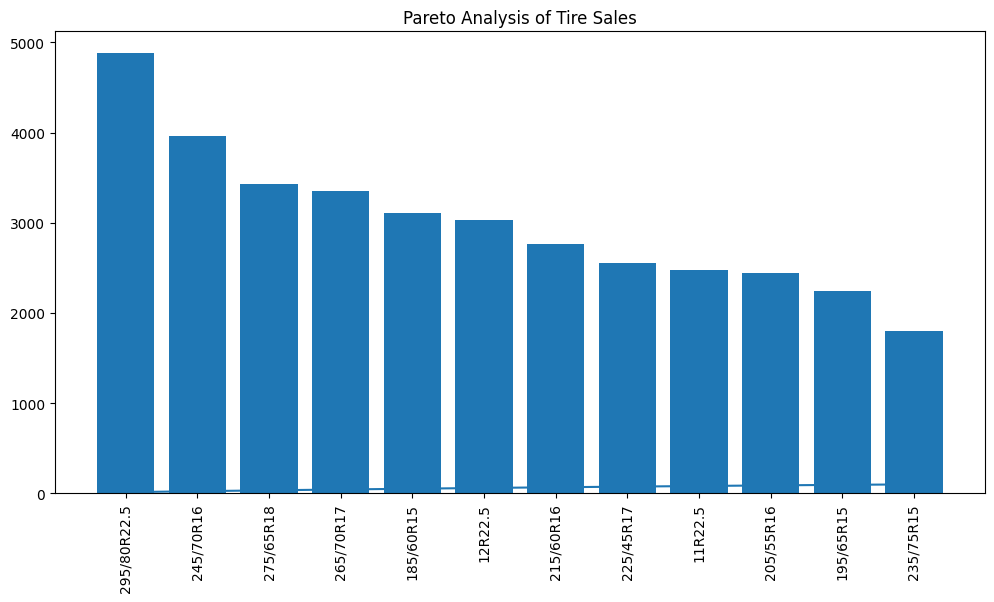

In [24]:
#Pareto analysis plot
plt.figure(figsize=(12,6))

plt.bar(
    pareto["medida"],
    pareto["ventas"]
)

plt.plot(
    pareto["medida"],
    pareto["porcentaje"]
)

plt.xticks(rotation=90)

plt.title("Pareto Analysis of Tire Sales")

plt.show()

In [25]:
resumen = historico.groupby(
    ["medida"]
).agg({
    "ventas":"sum",
    "inventario":"mean"
}).reset_index()

resumen.head()

,medida,ventas,inventario
0,11R22.5,2480,44.853175
1,12R22.5,3029,46.005882
2,185/60R15,3109,49.409804
3,195/65R15,2245,44.236111
4,205/55R16,2440,47.470635


In [26]:
resumen["rotacion"] = (
    resumen["ventas"] /
    resumen["inventario"]
)

resumen.sort_values(
    "rotacion",
    ascending=False
).head(10)

,medida,ventas,inventario,rotacion
11,295/80R22.5,4879,47.345267,103.051482
8,245/70R16,3963,44.133333,89.796073
10,275/65R18,3430,47.411111,72.345910
9,265/70R17,3353,47.174074,71.077177
1,12R22.5,3029,46.005882,65.839407
2,185/60R15,3109,49.409804,62.922735
5,215/60R16,2771,48.653472,56.953797
0,11R22.5,2480,44.853175,55.291516
6,225/45R17,2553,46.887302,54.449711
4,205/55R16,2440,47.470635,51.400197


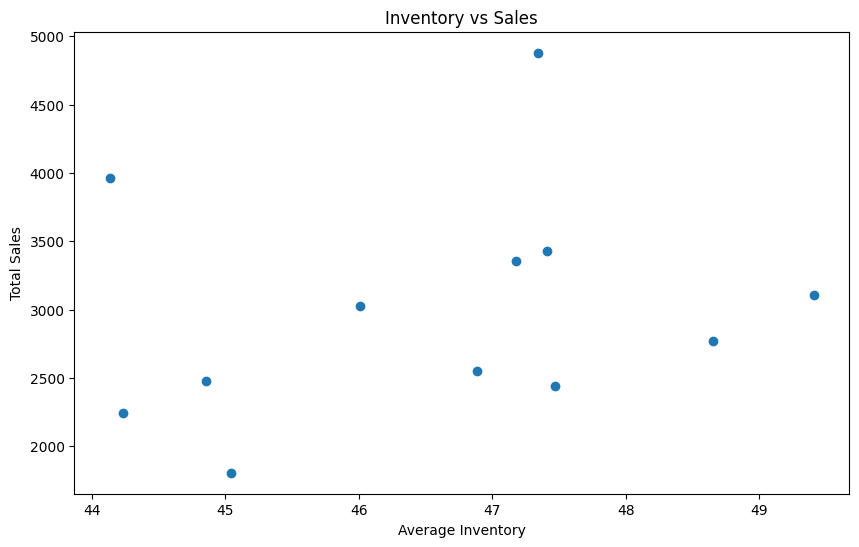

In [27]:
#inventory vs sales plot

plt.figure(figsize=(10,6))

plt.scatter(
    resumen["inventario"],
    resumen["ventas"]
)

plt.xlabel("Average Inventory")
plt.ylabel("Total Sales")
plt.title("Inventory vs Sales")

plt.show()

In [28]:
#final summary
resumen_final = historico.groupby(
    ["medida"]
).agg(
    ventas_totales=("ventas","sum"),
    inventario_promedio=("inventario","mean")
).reset_index()

resumen_final["rotacion"] = (
    resumen_final["ventas_totales"] /
    resumen_final["inventario_promedio"]
)

resumen_final = resumen_final.sort_values(
    "ventas_totales",
    ascending=False
)

resumen_final.head()

,medida,ventas_totales,inventario_promedio,rotacion
11,295/80R22.5,4879,47.345267,103.051482
8,245/70R16,3963,44.133333,89.796073
10,275/65R18,3430,47.411111,72.345910
9,265/70R17,3353,47.174074,71.077177
2,185/60R15,3109,49.409804,62.922735


In [29]:
resumen_final.to_csv(
    "resumen_ejecutivo.csv",
    index=False
)

print("Archivo generado")
from google.colab import files

files.download("resumen_ejecutivo.csv")

Archivo generado


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
catalogo = pd.read_csv("catalogo_llantas.csv")

catalogo.head()

,llanta_id,medida,marca,categoria,costo,inventario_inicial
0,1,245/70R16,Bridgestone,Pickup,1396,15
1,2,225/45R17,Continental,SUV,1795,67
2,3,11R22.5,Pirelli,SUV,3107,53
3,4,265/70R17,Firestone,Pickup,4446,54
4,5,215/60R16,Michelin,Camion,1751,41


In [31]:
catalogo.columns

Index(['llanta_id', 'medida', 'marca', 'categoria', 'costo',
       'inventario_inicial'],
      dtype='object')

In [32]:
costos_medida = (
    catalogo
    .groupby("medida")["costo"]
    .mean()
    .reset_index()
)

costos_medida.head()

,medida,costo
0,11R22.5,2921.785714
1,12R22.5,2878.235294
2,185/60R15,2869.588235
3,195/65R15,2868.083333
4,205/55R16,2931.857143


In [33]:
#financial summary

resumen_financiero = resumen_final.merge(
    costos_medida,
    on="medida",
    how="left"
)

resumen_financiero.head()

,medida,ventas_totales,inventario_promedio,rotacion,costo
0,295/80R22.5,4879,47.345267,103.051482,2653.925926
1,245/70R16,3963,44.133333,89.796073,2663.363636
2,275/65R18,3430,47.411111,72.345910,3111.368421
3,265/70R17,3353,47.174074,71.077177,2799.055556
4,185/60R15,3109,49.409804,62.922735,2869.588235


In [34]:
resumen_financiero["valor_inventario"] = (
    resumen_financiero["inventario_promedio"]
    * resumen_financiero["costo"]
)

resumen_financiero.head()

,medida,ventas_totales,inventario_promedio,rotacion,costo,valor_inventario
0,295/80R22.5,4879,47.345267,103.051482,2653.925926,125650.832861
1,245/70R16,3963,44.133333,89.796073,2663.363636,117543.115152
2,275/65R18,3430,47.411111,72.345910,3111.368421,147513.433918
3,265/70R17,3353,47.174074,71.077177,2799.055556,132042.854115
4,185/60R15,3109,49.409804,62.922735,2869.588235,141785.792042


In [35]:
top_capital = resumen_financiero.sort_values(
    "valor_inventario",
    ascending=False
)

top_capital.head(10)

,medida,ventas_totales,inventario_promedio,rotacion,costo,valor_inventario
2,275/65R18,3430,47.411111,72.345910,3111.368421,147513.433918
4,185/60R15,3109,49.409804,62.922735,2869.588235,141785.792042
9,205/55R16,2440,47.470635,51.400197,2931.857143,139177.120068
5,12R22.5,3029,46.005882,65.839407,2878.235294,132415.754325
3,265/70R17,3353,47.174074,71.077177,2799.055556,132042.854115
8,11R22.5,2480,44.853175,55.291516,2921.785714,131051.364796
10,195/65R15,2245,44.236111,50.750392,2868.083333,126872.853009
0,295/80R22.5,4879,47.345267,103.051482,2653.925926,125650.832861
7,225/45R17,2553,46.887302,54.449711,2560.571429,120058.284807
1,245/70R16,3963,44.133333,89.796073,2663.363636,117543.115152


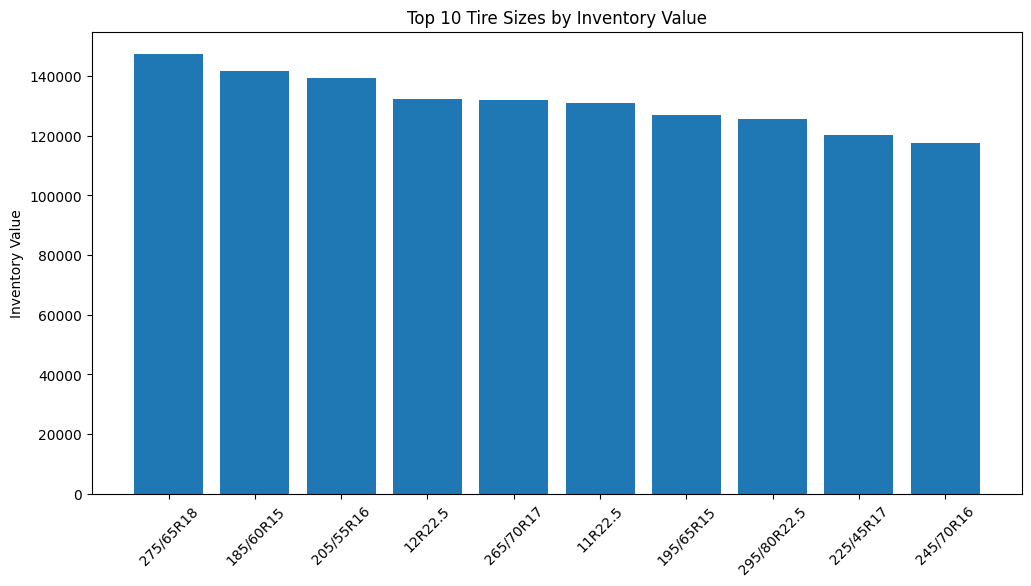

In [36]:
#top 10 tire sizes by inventory value
plt.figure(figsize=(12,6))

plt.bar(
    top_capital.head(10)["medida"],
    top_capital.head(10)["valor_inventario"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Tire Sizes by Inventory Value")
plt.ylabel("Inventory Value")

plt.show()

In [37]:
resumen_financiero.sort_values(
    "rotacion",
    ascending=False
).head(10)

,medida,ventas_totales,inventario_promedio,rotacion,costo,valor_inventario
0,295/80R22.5,4879,47.345267,103.051482,2653.925926,125650.832861
1,245/70R16,3963,44.133333,89.796073,2663.363636,117543.115152
2,275/65R18,3430,47.411111,72.345910,3111.368421,147513.433918
3,265/70R17,3353,47.174074,71.077177,2799.055556,132042.854115
5,12R22.5,3029,46.005882,65.839407,2878.235294,132415.754325
4,185/60R15,3109,49.409804,62.922735,2869.588235,141785.792042
6,215/60R16,2771,48.653472,56.953797,2384.687500,116023.327040
8,11R22.5,2480,44.853175,55.291516,2921.785714,131051.364796
7,225/45R17,2553,46.887302,54.449711,2560.571429,120058.284807
9,205/55R16,2440,47.470635,51.400197,2931.857143,139177.120068


In [38]:
resumen_financiero.sort_values(
    "valor_inventario",
    ascending=False
).head(10)

,medida,ventas_totales,inventario_promedio,rotacion,costo,valor_inventario
2,275/65R18,3430,47.411111,72.345910,3111.368421,147513.433918
4,185/60R15,3109,49.409804,62.922735,2869.588235,141785.792042
9,205/55R16,2440,47.470635,51.400197,2931.857143,139177.120068
5,12R22.5,3029,46.005882,65.839407,2878.235294,132415.754325
3,265/70R17,3353,47.174074,71.077177,2799.055556,132042.854115
8,11R22.5,2480,44.853175,55.291516,2921.785714,131051.364796
10,195/65R15,2245,44.236111,50.750392,2868.083333,126872.853009
0,295/80R22.5,4879,47.345267,103.051482,2653.925926,125650.832861
7,225/45R17,2553,46.887302,54.449711,2560.571429,120058.284807
1,245/70R16,3963,44.133333,89.796073,2663.363636,117543.115152


In [39]:
#products clasification
ventas_promedio = resumen_financiero["ventas_totales"].mean()
rotacion_promedio = resumen_financiero["rotacion"].mean()

resumen_financiero["categoria_negocio"] = "Otro"

resumen_financiero.loc[
    (resumen_financiero["ventas_totales"] >= ventas_promedio) &
    (resumen_financiero["rotacion"] >= rotacion_promedio),
    "categoria_negocio"
] = "Estrella"

resumen_financiero.loc[
    (resumen_financiero["ventas_totales"] < ventas_promedio) &
    (resumen_financiero["rotacion"] < rotacion_promedio),
    "categoria_negocio"
] = "Lenta"

resumen_financiero["categoria_negocio"].value_counts()

,count
categoria_negocio,
Lenta,6
Estrella,5
Otro,1


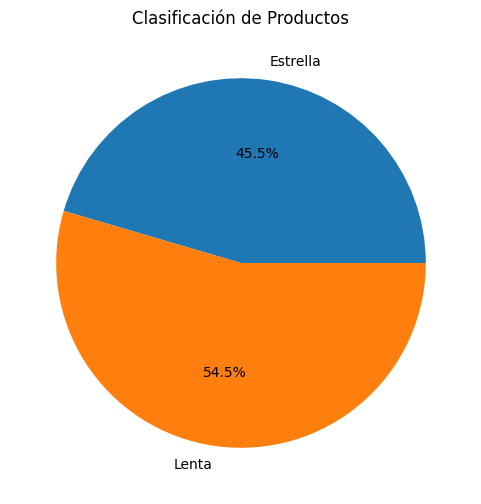

In [40]:
#products clasificacion plot
categorias = ["Estrella", "Lenta"]
cantidades = [5, 6]

plt.figure(figsize=(6,6))

plt.pie(
    cantidades,
    labels=categorias,
    autopct="%1.1f%%"
)

plt.title("Clasificación de Productos")

plt.show()

In [41]:
resumen_financiero.loc[
    resumen_financiero["categoria_negocio"] == "Otro",
    "medida"
]

,medida
4,185/60R15


In [42]:
resumen_financiero[
    resumen_financiero["categoria_negocio"] == "Estrella"
]

,medida,ventas_totales,inventario_promedio,rotacion,costo,valor_inventario,categoria_negocio
0,295/80R22.5,4879,47.345267,103.051482,2653.925926,125650.832861,Estrella
1,245/70R16,3963,44.133333,89.796073,2663.363636,117543.115152,Estrella
2,275/65R18,3430,47.411111,72.345910,3111.368421,147513.433918,Estrella
3,265/70R17,3353,47.174074,71.077177,2799.055556,132042.854115,Estrella
5,12R22.5,3029,46.005882,65.839407,2878.235294,132415.754325,Estrella


In [43]:
resumen_financiero[
    resumen_financiero["categoria_negocio"] == "Lenta"
]

,medida,ventas_totales,inventario_promedio,rotacion,costo,valor_inventario,categoria_negocio
6,215/60R16,2771,48.653472,56.953797,2384.687500,116023.327040,Lenta
7,225/45R17,2553,46.887302,54.449711,2560.571429,120058.284807,Lenta
8,11R22.5,2480,44.853175,55.291516,2921.785714,131051.364796,Lenta
9,205/55R16,2440,47.470635,51.400197,2931.857143,139177.120068,Lenta
10,195/65R15,2245,44.236111,50.750392,2868.083333,126872.853009,Lenta
11,235/75R15,1806,45.044444,40.093735,2462.200000,110908.431111,Lenta


In [44]:
ventas_totales = resumen_financiero["ventas_totales"].sum()

top3 = resumen_financiero.nlargest(
    3,
    "ventas_totales"
)

ventas_top3 = top3["ventas_totales"].sum()

porcentaje_top3 = (
    ventas_top3 / ventas_totales
) * 100

print(
    f"Top 3 generan {porcentaje_top3:.2f}% de las ventas"
)

top3

Top 3 generan 34.03% de las ventas


,medida,ventas_totales,inventario_promedio,rotacion,costo,valor_inventario,categoria_negocio
0,295/80R22.5,4879,47.345267,103.051482,2653.925926,125650.832861,Estrella
1,245/70R16,3963,44.133333,89.796073,2663.363636,117543.115152,Estrella
2,275/65R18,3430,47.411111,72.345910,3111.368421,147513.433918,Estrella


In [45]:
resumen_financiero.to_csv(
    "dashboard_tableau.csv",
    index=False
)

print("Archivo listo para Tableau")
from google.colab import files

files.download("dashboard_tableau.csv")

Archivo listo para Tableau


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

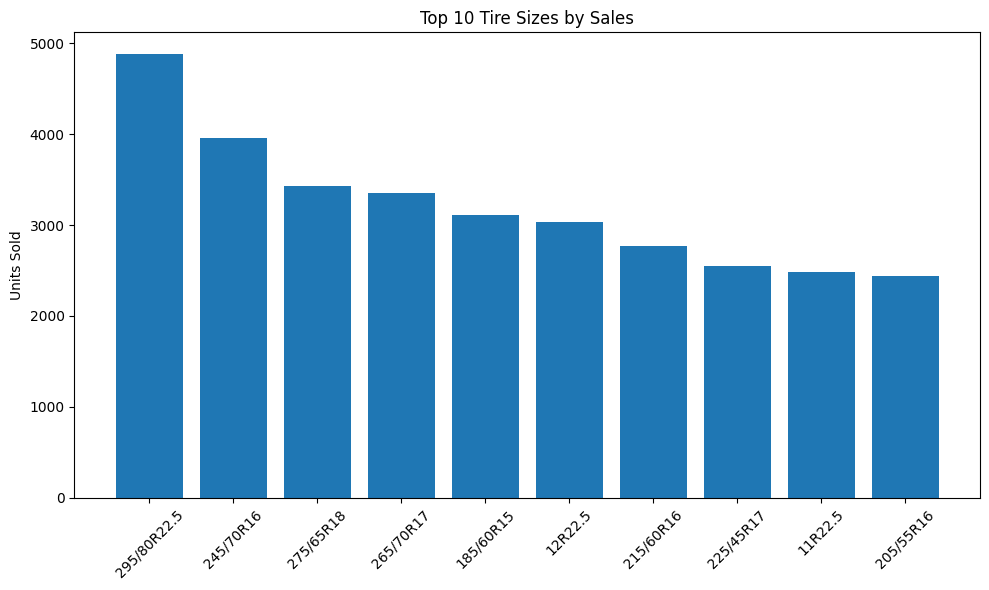

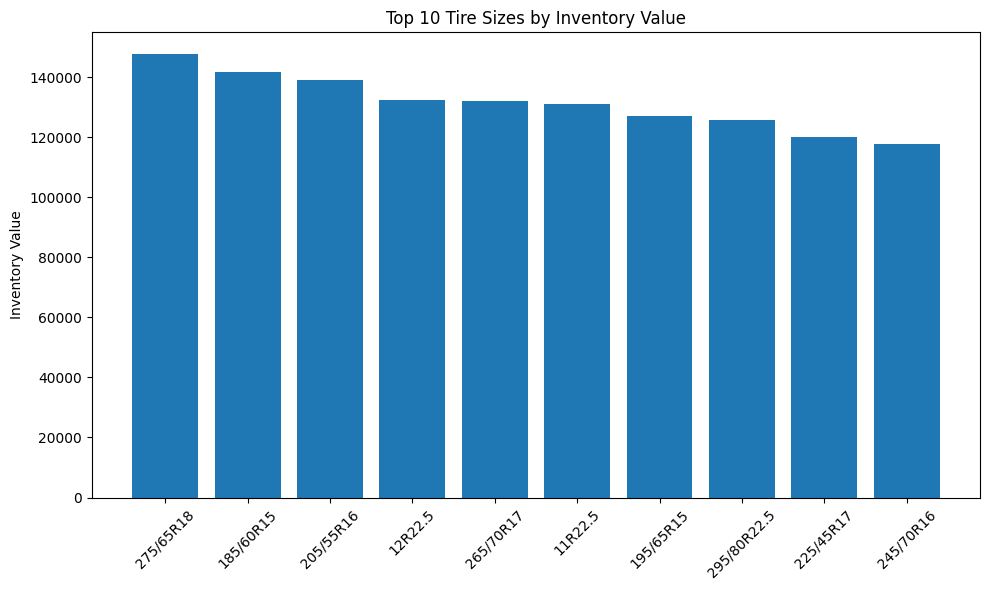

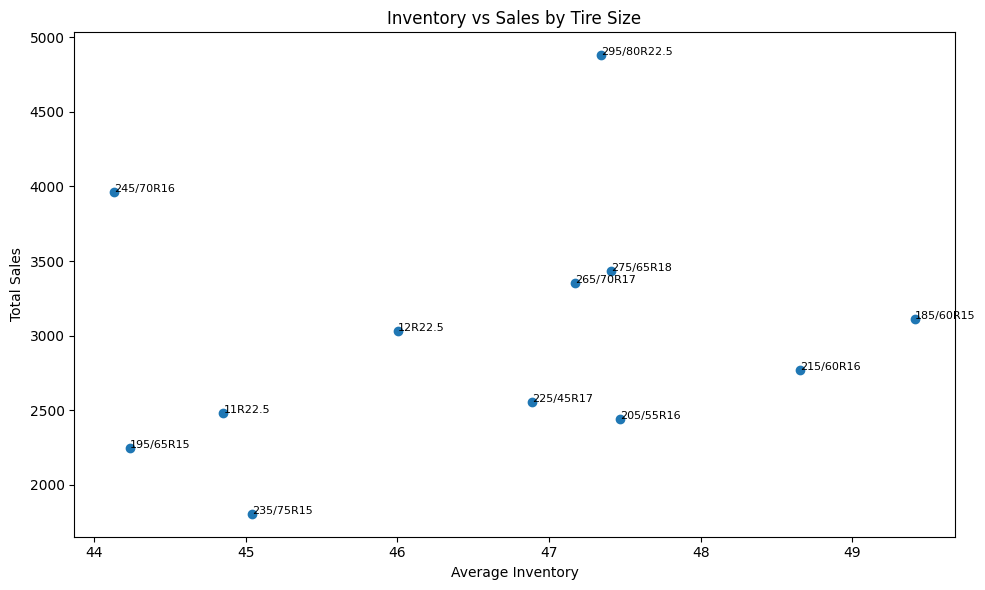

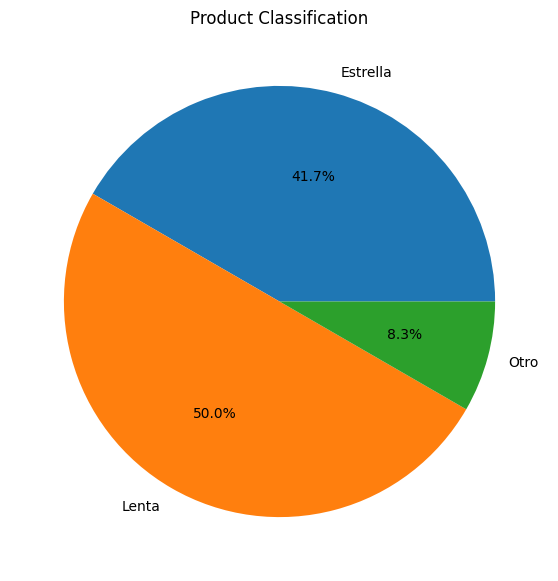

In [46]:
top10 = resumen_financiero.nlargest(
    10,
    "ventas_totales"
)

plt.figure(figsize=(10,6))

plt.bar(
    top10["medida"],
    top10["ventas_totales"]
)

plt.title("Top 10 Tire Sizes by Sales")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "top_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

top_valor = resumen_financiero.nlargest(
    10,
    "valor_inventario"
)

plt.figure(figsize=(10,6))

plt.bar(
    top_valor["medida"],
    top_valor["valor_inventario"]
)

plt.title("Top 10 Tire Sizes by Inventory Value")
plt.ylabel("Inventory Value")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "inventory_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(10,6))

plt.scatter(
    resumen_financiero["inventario_promedio"],
    resumen_financiero["ventas_totales"]
)

for _, row in resumen_financiero.iterrows():
    plt.annotate(
        row["medida"],
        (
            row["inventario_promedio"],
            row["ventas_totales"]
        ),
        fontsize=8
    )

plt.xlabel("Average Inventory")
plt.ylabel("Total Sales")

plt.title(
    "Inventory vs Sales by Tire Size"
)

plt.tight_layout()

plt.savefig(
    "inventory_vs_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

categorias = ["Estrella", "Lenta", "Otro"]
cantidades = [5, 6, 1]

plt.figure(figsize=(7,7))

plt.pie(
    cantidades,
    labels=categorias,
    autopct="%1.1f%%"
)

plt.title(
    "Product Classification"
)

plt.savefig(
    "product_classification.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
from google.colab import files

files.download("top_sales.png")
files.download("inventory_value.png")
files.download("inventory_vs_sales.png")
files.download("product_classification.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Key Findings

1. Total sales reached 36,058 units during the analysis period.

2. Average inventory levels remained at 46.65 units per product.

3. Tire size 295/80R22.5 generated the highest sales volume and inventory turnover.

4. Tire size 275/65R18 represented the largest inventory investment.

5. The top three tire sizes generated approximately 34% of total sales.

6. Five tire sizes were classified as Star Products while six were classified as Slow-Moving Products.

# Recommendations

## Recommendation 1

Prioritize replenishment of high-performing products, particularly 295/80R22.5.

## Recommendation 2

Monitor inventory investment in 275/65R18 to ensure inventory levels remain aligned with demand.

## Recommendation 3

Review purchasing policies for slow-moving products to reduce excess inventory.

## Recommendation 4

Continue developing inventory analytics to support data-driven purchasing decisions.
# Future Improvements

Future versions of this project may include:

- Real inventory data integration
- Automated inventory updates
- Demand forecasting models
- Interactive dashboards
- Purchasing recommendation systems